# Logistic Regression

In [1]:
# importiamo i pacchetti necessari
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from  sklearn.linear_model import LogisticRegressionCV
from sklearn.multiclass import OneVsRestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn import metrics
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import TimeSeriesSplit

%load_ext autoreload
%autoreload 2
import sys
sys.path.append('../..')

import src.class_funcs as fs

from IPython.display import Image, display

In [2]:
# scelta del seed random per la riproducibilità dei risultati
seed = 0

## Studio binario

Tramite questo studio di classificazione vogliamo essere in grado di effettuare previsioni sull'inquinamento dell'aria.\
Per sfruttare al massimo le conoscenze sviluppate in classe, scriviamo inizialmente il problema come un preblema di carattere binario. In particolare, etichettiamo come 1 = 'ok' tutti i punti con EAQI 'good' o 'fair' (AQI < 40), mentre chiamiamo 0 = 'not ok' i restanti punti con EAQI 'moderate', 'poor' o 'very poor'. Data una certa ora, cerchiamo quindi di prevedere se la qualità dell'aria sarà 'ok' o 'not ok' sulla base delle rilevazioni nelle ore a questa precedenti.

Costruiamo quindi il dataframe inserendo le ore precedenti a quella di target come specificato sopra.

Seppure la colonna 'winds_spd' sia molto correlata con gli inquinanti, contenendo diversi NaN, scegliamo per il momento di escluderla. L'influenza di questa feature sulle previsioni è approfondita nel notebook di appendice.

In [3]:
binary_class_df = pd.read_csv('../../data/processed/dataset_binary_class_processed.csv')

# togliamo la colonna 'winds_spd'
binary_class_df.drop('winds_spd', axis=1, inplace=True)

binary_class_df.head()

,station_Borgo Valsugana,station_Monte Gaza,station_Parco S. Chiara,station_Piana Rotaliana,station_Riva del Garda,station_Rovereto,station_Via Bolzano,elevation,day,cos_week_day,...,PM10_3,NO2_3,AQI_3,power_area_50_3,temperature,precipitation,PM10_diff,NO2_diff,AQI_diff,target
0,1,0,0,0,0,0,0,410,1,-0.900969,...,19.0,19.0,24.0,17.861264,10.950,0.0,1.0,1.0,4.0,1
1,1,0,0,0,0,0,0,410,1,-0.900969,...,20.0,17.0,22.0,14.669913,11.000,0.0,-2.0,-2.0,0.0,1
2,1,0,0,0,0,0,0,410,1,-0.900969,...,21.0,18.0,26.0,16.969367,10.925,0.0,5.0,0.0,6.0,1
3,1,0,0,0,0,0,0,410,1,-0.900969,...,19.0,16.0,26.0,15.329278,10.950,0.0,-5.0,-1.0,-10.0,1
4,1,0,0,0,0,0,0,410,1,-0.900969,...,24.0,16.0,32.0,17.519438,11.550,0.0,3.0,0.0,2.0,1


### Discussione time-series dataset
Il nostro dataset di riferimento non è fatto di punti indipendenti, ma ordinati temporalmente. Per questo motivo utilizzare i metodi standard visti in classe creerebbe diversi data leakage più o meno importanti.
Tenendo conto di questa osservazione apportiamo le seguenti modifiche:
- Suddividiamo cronologicamente il dataset in train, valid e test: per fare in modo che il modello non colga informazioni dal futuro, scegliamo di ordinare nel tempo le tre sezioni in cui dividiamo il dataset.
- Al posto di usare la cross-validation standard, utilizziamo la cross-validation implementata in TimeSeriesSplit ("cross-validation on a rolling basis")

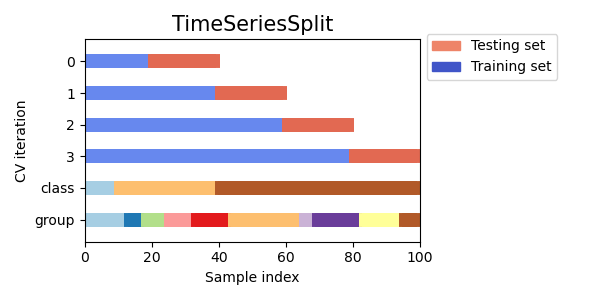

In [4]:
# per rendere più chiaro quello che stiamo facendo, riportiamo l'immagine trovata sul sito di sickit-learn
display(Image(filename='../../images/sphx_glr_plot_cv_indices_013.png'))

### Pipeline
Dato che la procedura standardizzazione-fit/predict verrà usata molto, vogliamo provare ad automatizzare questo processo usando una pipeline. Nella pipeline vogliamo fare in modo che vengano standardizzate solo alcune colonne e non altre.

La pipeline è particolarmente appropriata nel nostro caso perché, usando la cross validation autoimplementata in sickit-learn, la pipeline riscala il train ad ogni iterazione del k-fold, per cui si evita leakage interno al train.

In [6]:
# individuiamo le colonne numeriche e quelle non numeriche
non_num_features = [col for col in binary_class_df.columns if col.startswith('station_')]
num_features = binary_class_df.columns.difference(non_num_features + ['target'])

# per il preprocessing usiamo ColumnTransformer, che permette di trasformare diverse colonne in modo diverso
preprocessor_binary = ColumnTransformer(
    [('num', StandardScaler(), num_features),
     ('one-hot', 'passthrough', non_num_features)])

tscv = TimeSeriesSplit(n_splits=5)

classifier_binary = LogisticRegressionCV(
    Cs=10,                                                          # numero di C = 1/lambda testati
    cv=tscv,                                                        # cv = n => n-fold cross validation
    solver='saga',                                                  # scegliamo saga, che è l'unico che supporta elasticnet
    l1_ratios=[0,0.25,0.5,0.75,1.0],                                # ratei tra l1 e l2 da testare
    scoring=metrics.make_scorer(metrics.matthews_corrcoef),         # usiamo mcc come score perché le classi sono sbilanciate e non abbiamo preferenze tra fpr e fnr
    max_iter=5000,                                                  # numero massimo di iterazioni per l'ottimizzazione
    n_jobs = -1,                                                    # usiamo la massima potenza disponibile nella CPU
    class_weight='balanced',                                        # bilancia in automatico le classi in base alla frequenza di input
    random_state=seed)                                              # per la riproducibilità dei risultati

# costruiamo la nostra pipeline vera e propria
model_binary = Pipeline(steps=[('preprocessor', preprocessor_binary),('classifier', classifier_binary)])

### Train, Valid, Test split + fit
Dividiamo quindi il dataset in train (70%), valid (15%) e test (15%). Utilizziamo la cross-validation k-fold già implementata in LogisticRegressionCV. Introduciamo valid come insieme su cui scegliere il threshold più adatto per la logistic regression. Dopo aver scelto quest'ultima, rialleniamo il modello su train + valid e lo testiamo su test.

In [ ]:
# splittiamo il dataset e facciamo il fit al modello
feature_cols = list(num_features) + list(non_num_features)

# creiamo train, valid e test
bi_X_train, bi_X_valid, bi_X_test, bi_y_train, bi_y_valid, bi_y_test = fs.get_train_valid_test(binary_class_df, 0.7, 0.15, feature_cols)

In [ ]:
# alleniamo il modello sul nostro insieme di training
model_binary.fit(bi_X_train,bi_y_train)

### Studio importanza features
Quali sono le features più importanti?

In [ ]:
# tiro fuori i nomi delle feature come li ha presi il trasformatore (in questo modo non rischio di scambiare le features)
feature_names = model_binary.named_steps['preprocessor'].get_feature_names_out()

# rappresento il valore assoluto dei coefficienti
fs.display_abs_coefs(model_binary.named_steps['classifier'],feature_names)

Come ci potevamo aspettare, le feature più importanti sono quelle con le indicazioni sugli inquinanti nelle ore precedenti quella in studio. In mezzo a questi si inserisce il ciclo giornaliero, che, come visto nell'EDA, ha delle fluttuazioni caratteristiche e rilevanti.

Feature rilevante è anche il dato sui consumi elettrici tre ore prima dell'ora in studio. Particolarmente interessante è proprio che il dato rilevante è proprio quello di tre ore prima. Probabilmente questo è dovuto al fatto che, come visto, la correlazione tra inquinanti e consumi aumentava leggermente aumentando il delay, raggiungendo un massimo e poi diminuendo. Magari le altre features sull'energia sono particolarmente meno rilevanti perché portano più o meno la stessa informazione della feature relativa a tre ore prima.

Interessante è anche il fatto che le stazioni non sembrano particolarmente rilevanti nello studio. Magari è anche dovuto al fatto che, andando in ordine cronologico, non vengono fuori le grandi differenze tra le stazioni che si vedono verso Natale.

Stranamente i dati meteo sono irrilevanti. Ci saremmo aspettati una dipendenza maggiore, ma forse questo dato è dovuto all'intervallo di tempo molto limitato in studio.

### Studio matrici di confusione
Studiamo quindi le matrici di confusione per train e valid, capiamo come si comporti il nostro modello ed individuiamo un eventuale overfitting

In [ ]:
fs.display_confusion_matrix(model_binary, 'Confusion matrix train', bi_X_train, bi_y_train, 'Confusion matrix valid', bi_X_valid, bi_y_valid)

fs.get_performance_param(model_binary, bi_X_valid, bi_y_valid)

Non sembra ci sia overfitting, ma i risultati sono comunque molto rumorosi.

Una cosa da tenere a mente e che è particolarmente evidente qui è il progressivo peggioramento della qualità dell'aria nell'andare verso Natale. Avendo a disposizione un intervallo di tempo così limitato, questo vuol dire che in realtà l'insieme di train sarà abbastanza diverso da quello di valid e test, con questi ultimi due che avrenno una frazione di 'not ok' molto maggiore rispetto al train.
Sempre guardando l'andamento temporale della qualità dell'aria, ci possiamo aspettare che la performance sul test sarà migliore di quella sul valid, visto che quest'ultimo è composto per una gran parte da giorni successivi a Natale e quindi è più simile al train come distribuzione dei punti.

Detto ciò, anche guardando i parametri di performance, sembra che per una semplice logistic regression il modello funzioni piuttosto bene.Il dato peggiore è l'MCC, che comunque non è il massimo visto che è il parametro che vorremmo massimizzare. 

Proviamo a migliorare l'MCC scegliendo il miglior threshold su valid nella prossima sezione.

### Ottimizzazione del threshold
Avendo delle classi molto sbilanciate, siamo interessati ad ottimizzare il threshold utilizzando l'MCC come parametro da massimizzare.

Anche sapendo questo, può essere interessante ed educativo passare prima attraverso la curva ROC e Precision-Recall. Inoltre, vogliamo valutare anche metodi diversi per scegliere il miglior threshold.

In [ ]:
# disegnamo la curva ROC e Precision-Recall
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

y_proba_va = model_binary.predict_proba(bi_X_valid)[:, 1] # restituisce le predizioni in forma di probabilità, quindi permette di disegnare la ROC

# parametri per la curva ROC
fpr,tpr,thr = metrics.roc_curve(bi_y_valid,y_proba_va)

ax0 = axes[0]
sns.lineplot(x=fpr, y=tpr, ax=ax0)
ax0.set_xlabel('False Positive Rate')
ax0.set_ylabel('True Positive Rate')
ax0.grid()

# parametri per la curva Precision-Recall
prec,rec,thr = metrics.precision_recall_curve(bi_y_valid,y_proba_va)

ax1 = axes[1]
sns.lineplot(x=prec, y=rec, ax=ax1)
ax1.set_xlabel('Precision')
ax1.set_ylabel('Recall')
ax1.grid()

plt.tight_layout()

Come aspettato, vista la performance abbastanza buona del modello, la curva ROC è molto lontana dalla diagonale (molto poco casuale) e anche la curva Precision-Recall è molto spostata verso l'angolo in alto a destra.

Rappresentiamo anche curva Precision e Recall separate in funzione del threshold

In [ ]:
ax = sns.lineplot(x=thr, y=prec[:-1], label='precision')
sns.lineplot(x=thr,y=rec[:-1],label='recall',color='red', ax=ax)
ax.set_xlabel('Threshold')
ax.set_ylabel('Precision / Recall')
ax.minorticks_on()
ax.grid(visible= True)

Come aspettato, la precision = TP / PP aumenta all'aumentare del threshold, andando a 1 per il threshold che diventa 1:\
per thr -> 1, TP -> 0 e PP -> 0 => prec -> 1, per thr -> 0, TP -> AP e PP -> n => prec -> AP / n, è ≠ 0.5 se le classi sono sbilanciate

Al contrario, il recall = TP / AP diminuisce all'aumentare del threshold:\
per thr -> 1, TP -> 0 e AP = const => rec -> 0, per thr -> 0, TP -> AP => rec -> 1

Possiamo scegliere il threshold in diversi modi:
1. non volendo assegnare costi diversi ad una classe rispetto all'altra, una retta a pari performance (cioè a pari costo) nel grafico della ROC è una retta con coefficiente angolare P(N) / P(P) = #N / #P. In questa ottica, il threshold migliore è quindi il threshold che massimizza l'intercetta di questa retta (punto in cui la retta è tangente);

2. guardando online, un altro metro di scelta basato sulla ROC è la statistica J di Youden (si veda https://en.wikipedia.org/wiki/Youden%27s_J_statistic). In pratica il punto con migliore threshold è il punto che massimizza il valore J = sensitivity + specificity - 1 = TPR - FPR;

3. si può scegliere il threshold come punto di intersezione tra Precision e Recall. In questo modo non preferiamo una curva all'altra;

4. studiando il F1-score, si può scegliere il threshold che massimizza questo parametro, anche se questo è più adatto ai contesti in cui ci interessano particolarmente i positivi;

5. studiando il Matthews Correlation Coefficient (MCC), si può scegliere il threshold che massimizza questo parametro. In generale, questo studio è particolarmente adatto allo studio di classi sbilanciate, che è proprio il nostro caso.

Dopo aver comparato sull'insieme di validazione i diversi threshold ottenuti in questo modo, rialleniamo il modello e passiamo finalmente alla valutazione della predittività del modello sull'insieme di test.

In [ ]:
y_proba_va = model_binary.predict_proba(bi_X_valid)[:, 1]

# 1. Intercetta
num_P = bi_y_valid.sum()
num_N = len(bi_y_valid) - num_P

fpr,tpr,thr_roc = metrics.roc_curve(bi_y_valid,y_proba_va)

mx = (num_N /num_P) * fpr
intercept = tpr[:-1] - mx[:-1]

best_idx = np.argmax(intercept)
best_thr_int = thr_roc[best_idx]
print(f'Threshold metodo intercetta: {best_thr_int:.5f}')

# 2. statistica J di Youden
J_score = tpr[:-1] - fpr[:-1]

best_idx = np.argmax(J_score)
best_thr_J = thr_roc[best_idx]
print(f'Threshold statistica J di Youden: {best_thr_J:.5f}')

# 3. intersezione Precision-Recall
prec,rec,thr_pre = metrics.precision_recall_curve(bi_y_valid,y_proba_va)

best_idx = np.argmin(np.abs(prec[:-1] - rec[:-1]))
best_thr_PR = thr_pre[best_idx]
print(f'Threshold intersezione Precision-Recall: {best_thr_PR:.5f}')

# 4. F1-score
f1_score = 2 * (prec[:-1] * rec[:-1]) / (prec[:-1] + rec[:-1])
best_idx = np.argmax(f1_score)
best_thr_f1 = thr_pre[best_idx]
print(f'Threshold F1-score: {best_thr_f1:.5f}')

thr = np.linspace(0, 1, int(1e3))

# 5. MCC
max_MCC_score = -1
best_thr_MCC = None

for t in thr:
    y_pred = (y_proba_va >= t).astype(int)
    MCC_score = metrics.matthews_corrcoef(bi_y_valid, y_pred)

    if (MCC_score > max_MCC_score):
        max_MCC_score = MCC_score
        best_thr_MCC = t


print(f'Threshold MCC: {best_thr_MCC:.5f}')

È interessante notare come la scelta della migliore threshold si riduca sostanzialmente a due possibilità:
- una threshold "alta", per i metodi dell'intercetta e dell'intersezione tra curve Precision e Recall.
- una threshold "bassa", per i restanti tre metodi.

Il primo di questi due gruppi ha un approccio tendenzialmente più neutro di fronte allo sbilanciamento delle classi, che qui è particolarmente rilevante. In particolare, il risultato sull'intercetta potrebbe anche essere dovuto al fatto che, mentre train è molto sbilanciato sulla classe 1, valid sembra avere molto meno sbilanciamento, per cui la situazione è diversa.

In ogni caso, come preannunciato, scegliamo il coefficiente di correlazione di Matthews come metrica da massimizzare.

### Retrain su train + valid e studio di test

In [ ]:
# uniamo train e valid
bi_X_train_valid = pd.concat([bi_X_train, bi_X_valid], ignore_index=True)
bi_y_train_valid = pd.concat([bi_y_train, bi_y_valid], ignore_index=True)

# alleniamo il modello
model_binary.fit(bi_X_train_valid,bi_y_train_valid)

In [ ]:
fs.display_confusion_matrix(model_binary, 'Confusion matrix train + valid', bi_X_train_valid, bi_y_train_valid, 'Confusion matrix test', bi_X_test, bi_y_test, best_thr_MCC)

fs.get_performance_param(model_binary, bi_X_test, bi_y_test, thr=best_thr_MCC)

Come previsto, il risultato sul test è molto migliore di quanto non fosse per il valid. Questo è sicuramente dovuto, almeno in parte, dalla scelta del threshold ottimale, mentre un contributo viene anche dall'allenamento su un insieme di cardinalità maggiore e dal fatto che i dati del test sono distribuiti in modo più simile al train.

In generale, anche guardando i parametri di performance, possiamo ritenere il modello sufficientemente predittivo per una semplice logistic regression. Sicuramente l'intervallo di tempo così limitato ed la variazione del trend degli inquinanti nel tempo non aiutano all'allenamento di un modello particolarmente efficace.

Successivamente proveremo a riaffrontare il problema usando la Random Forest, che ci aspettiamo riesca a produrre risultati migliori.

Passiamo quindi a discutere brevemente il problema multiclasse in cui consideriamo tutte le classi dell'EAQI. In generale ci aspettiamo risultati peggiori rispetto a quelli dello studio binario, ma vogliamo comunque capire se riusciamo a tirarci fuori qualcosa di utilizzabile o no.

## Classificazione a 5 classi

In [ ]:
# cominciamo importando il dataframe precedentemente preparato
multiclass_df = pd.read_csv('../../data/processed/dataset_multiclass_processed.csv')

# come fatto per il problema binario togliamo la colonna 'winds_spd'
multiclass_df.drop('winds_spd', axis=1, inplace=True)

# droppiamo poi anche diverse righe contenenti NaN
multiclass_df.dropna(inplace=True) 

multiclass_df.head()

In [ ]:
# contiamo al volo il numeo di punti per ciascuna classe
multiclass_df['target'].value_counts()

Notiamo come le classi sono profondamente sbilanciate. In particolare la cardinalità di 'very poor' è molto minore rispetto a tutte le altre classi ed immaginiamo sarà particolarmente concentrata verso metà dicembre. Teniamo a mente questo per la fase di validazione del modello.

### Pipeline
Provando ad allenare il modello multiclasse con 'saga', l'elasticnet e gli stessi parametri di prima, notiamo che nessun modello allenato raggiunge la convergenza entro 10000 iterazioni. Per evitare che l'allenamento sia troppo costoso, proviamo a cambiare il solver e rinunciamo all'elasticnet per lo studio.

In particolare passiamo al solver 'lbfgs', che dovrebbe essere più rapido a convergere, ma che supporta solo il regolarizzatore di Ridge. Visto che stiamo cedendo sull'elasticnet, aumentiamo a 20 il numero di lambda da testare.

In [ ]:
# individuiamo le colonne numeriche e quelle non numeriche
non_num_features = [col for col in multiclass_df.columns if col.startswith('station_')]
num_features = multiclass_df.columns.difference(non_num_features + ['target'])

# per il preprocessing usiamo ColumnTransformer, che permette di trasformare diverse colonne in modo diverso
preprocessor_multiclass = ColumnTransformer(
    [('num', StandardScaler(), num_features),
     ('one-hot', 'passthrough', non_num_features)])

tscv = TimeSeriesSplit(n_splits=5)

classifier_multiclass = LogisticRegressionCV(
    Cs=20,                                                          # numero di C = 1/lambda testati
    cv=tscv,                                                        # cv = n => n-fold cross validation
    solver='lbfgs',                                                 # scegliamo lbfgs
    l1_ratios=[0.0],                                                # alleniamo due modelli, rispettivamente con l2 e l1
    scoring=metrics.make_scorer(metrics.matthews_corrcoef),         # usiamo mcc come score perché le classi sono sbilanciate e non abbiamo preferenze tra fpr e fnr
    max_iter=5000,                                                  # numero massimo di iterazioni per l'ottimizzazione
    n_jobs = -1,                                                    # usiamo la massima potenza disponibile nella CPU
    class_weight='balanced',                                        # bilancia in automatico le classi in base alla frequenza di input
    random_state=seed,                                              # per la riproducibilità dei risultati
    use_legacy_attributes=False                                     # uso per evitare warning
)

# costruiamo la nostra pipeline vera e propria
model_multiclass = Pipeline(steps=[('preprocessor', preprocessor_multiclass),('classifier', classifier_multiclass)])

### Train, Test split
Per il caso dello studio multiclasse, la scelta del threshold sarebbe particolarmente pesante visto che andrebbero scelti molteplici threshold. Pertanto dividiamo solo in train e test e studiamo il modello. Scegliamo di dare al train l'80% dei dati ed al test il restante 20%.

In [ ]:
# splittiamo il dataset e facciamo il fit al modello
feature_cols = list(num_features) + list(non_num_features)

# creiamo train, valid e test
mc_X_train, mc_X_valid, mc_X_test, mc_y_train, mc_y_valid, mc_y_test = fs.get_train_valid_test(multiclass_df, 0.8, 0.0, feature_cols)

In [ ]:
model_multiclass.fit(mc_X_train,mc_y_train)

Vediamo quanto bene prevede il nostro modello.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15,6))

class_order = ['good', 'fair', 'moderate', 'poor', 'very poor']

ax0 = axes[0]
y_pred_tr = model_multiclass.predict(mc_X_train)
metrics.ConfusionMatrixDisplay.from_predictions(mc_y_train,y_pred_tr,display_labels=class_order, labels=class_order, ax=ax0)
ax0.set_title('Confusion matrix train')

ax1 = axes[1]
y_pred_te = model_multiclass.predict(mc_X_test)
metrics.ConfusionMatrixDisplay.from_predictions(mc_y_test,y_pred_te,display_labels=class_order, labels=class_order, ax=ax1)
ax1.set_title('Confusion matrix test')

plt.tight_layout()

plt.show()

fs.get_performance_param(model_multiclass, mc_X_test, mc_y_test, binary=False)

Sia dalla confusion matrix, che dai parametri di performance sembra che il nostro modello non sia molto predittivo.\
La classe 'very poor' viene predetta male più volte di quanto non venga predetta bene e, in particolare, quelle volte che viene predetta male, dembra venga scambiata con la classe 'poor'.

Proviamo quindi ad unire le classi 'poor' e 'very poor' e a capire se la performance del nostro classificatore migliora. Immaginiamo che in questo modo il classificatore assegni features molto più "negative" a 'poor', togliendo quindi anche parte delle confusioni tra 'poor' e 'moderate'

## Studio a 4 classi

In [ ]:
mod_multiclass_df = multiclass_df.copy()

# sostituiamo i 'very poor' nella colonna
mod_multiclass_df['target'] = mod_multiclass_df['target'].replace('very poor', 'poor')

mod_multiclass_df['target'].value_counts()

In questo modo stiamo anche rendendo le classi più bilanciate.

Rialleniamo il modello

In [ ]:
# creiamo train, valid e test
mmc_X_train, mmc_X_valid, mmc_X_test, mmc_y_train, mmc_y_valid, mmc_y_test = fs.get_train_valid_test(mod_multiclass_df, 0.8, 0.0, feature_cols)

model_multiclass.fit(mmc_X_train, mmc_y_train)

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15,6))

class_order = ['good', 'fair', 'moderate', 'poor']

ax0 = axes[0]
y_pred_tr = model_multiclass.predict(mmc_X_train)
metrics.ConfusionMatrixDisplay.from_predictions(mmc_y_train,y_pred_tr,display_labels=class_order, labels=class_order, ax=ax0)
ax0.set_title('Confusion matrix train')

ax1 = axes[1]
y_pred_te = model_multiclass.predict(mmc_X_test)
metrics.ConfusionMatrixDisplay.from_predictions(mmc_y_test,y_pred_te,display_labels=class_order, labels=class_order, ax=ax1)
ax1.set_title('Confusion matrix test')

plt.tight_layout()

plt.show()

fs.get_performance_param(model_multiclass, mmc_X_test, mmc_y_test, binary=False)

Vediamo dicuramente dei miglioramenti per quanto riguarda la nuova classe 'poor' che adesso ingloba anche 'very poor', ma per il resto la situazione sembra addirittura peggiorare. Questa volta è 'good' ad essere predetto male più volte che no, anche se bisogna notare che anche in precedenza questa classe era scambiata quasi il 50% delle volte per 'fair'.

Abbiamo provato a cambiare le feature, aggiungendo per esempio gli inquinanti 24 ore prima oppure la media degli inquinanti nelle ore precedenti a quella da studiare, ma la situazione non migliora.

Nella logistic regression implementata fino ad ora viene usato in automatico Softmax per la risoluzione del problema multiclasse. Abbiamo provato ad utilizzare invece una strategia OnevsRest per vedere se la situazione migliora, ma anzi, vediamo un netto peggioramento, per cui non riportiamo neanche lo studio.

Per il momento sembra che con i dati ed i mezzi a disposizione non si riescano a fare grandi predizioni su più di due classi. Rimandiamo allo studio della Random Forest la sentenza definitiva.

## Classificazione giornaliera
Per concludere lo studio sulla logistic regression proviamo a rispondere ad una nuova domanda: "riusciamo a prevedere come sarà la qualità dell'aria un certo giorno avendo informazioni su inquinamento, meteo e consumi energetici per i giorni prima?"

La domanda è quindi molto simile a quella precedente, ma lavoriamo con i giorni invece che con le ore. Cambiando in questo modo il problema dobbiamo chiaramente anche cambiare le feature e, in generale, lavoreremo con molti meno punti.

Visti i risultati dello studio multiclasse sulle ore, che avevano decisamente più punti, immaginiamo una performance molto peggiore nel caso dei giorni. Per tale motivo ci limitiamo al problema binario 1 = 'ok', 0 = 'not ok', come visto nella prima parte del notebook.

### Importiamo il notebook

In [ ]:
daily_class_df = pd.read_csv('../../data/processed/dataset_daily_class_processed.csv')

# togliamo la colonna 'winds_spd'
binary_class_df.drop('winds_spd', axis=1, inplace=True)

# droppiamo poi anche diverse righe contenenti NaN sulle rilevazioni degli inquinanti (probabilmente dovute a malfunzionamenti dei sensori)
# in questo modo cancelliamo anche le righe legate alle rilevazioni di Riva del Garda visto che questa stazione è staccata dalla linea elettrica
binary_class_df.dropna(inplace=True)

binary_class_df.head()